# **Proyecto: Análisis de Desigualdad en el Transporte Público**

**Descripción:** Este script primeramente instala altair y luego procesa los datos de frecuencia de buses y genera una visualización interactiva para analizar la brecha entre zonas centrales y periféricas.

In [ ]:
!pip install altair vl-convert-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 61.5 MB/s eta 0:00:00


In [4]:
import pandas as pd

# Se pide que lea el CSV
df_final = pd.read_csv('datos_procesados.csv')

# Revisa si hay datos vacíos
df_final = df_final.dropna(subset=['Código Usuario', 'TIPO_ZONA'])

df_final.head()

,Unidad de Negocio,Código TS,Código Usuario,Sentido,FREC_PUNTA,FREC_VALLE,INDICE_PUNTA_VALLE,CAP_POR_BUS_PUNTA,TIPO_ZONA
0,9,930c,F10c,Ida,5.291667,0.111111,47.62500,90.0,Periférica
1,13,1329c,429c,Ida,5.125000,0.133333,38.43750,90.0,Periférica
2,11,1122c,B12c,Ret,5.208333,0.222222,23.43750,90.0,Periférica
3,9,945e,F25e,Ret,4.250000,0.222222,19.12500,90.0,Periférica
4,12,1237c,117c,Ida,4.708333,0.266667,17.65625,90.0,Central


#**Generación de la Visualización Interactiva**

En esta sección se usa la altair para crear un gráfico que compara la frecuencia de buses entre el horario valle y el horario punta.

alt.LayerChart(...)

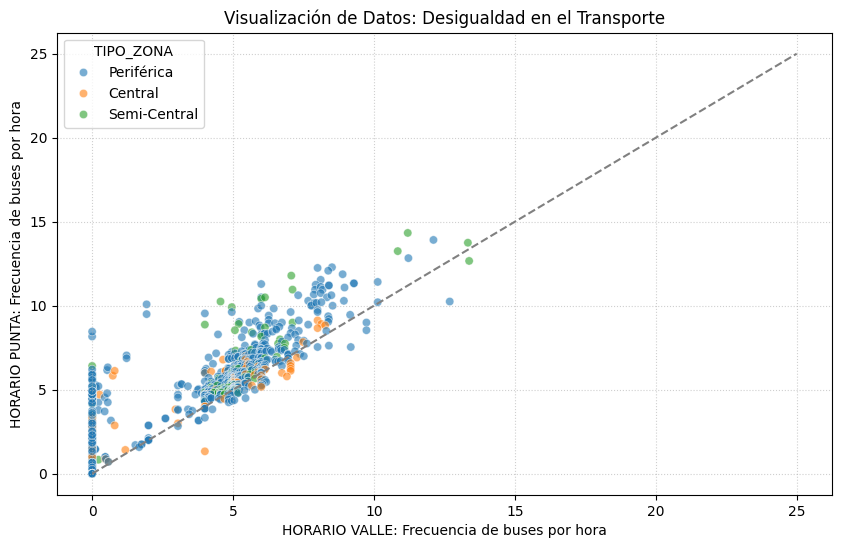

In [5]:
import altair as alt
import matplotlib.pyplot as plt
import seaborn as sns

# Gráfica Interactiva
puntos = alt.Chart(df_final).mark_circle(size=90, opacity=0.7).encode(
    x=alt.X('FREC_VALLE:Q', title='HORARIO VALLE: Frecuencia de buses por hora'),
    y=alt.Y('FREC_PUNTA:Q', title='HORARIO PUNTA: Frecuencia de buses por hora'),
    color=alt.Color('TIPO_ZONA:N', title='Zona de la Ciudad'),
    tooltip=[
        alt.Tooltip('Código Usuario:N', title='Código de bus'),
        alt.Tooltip('TIPO_ZONA:N', title='Zona'),
        alt.Tooltip('FREC_PUNTA:Q', title='Frecuencia Punta'),
        alt.Tooltip('FREC_VALLE:Q', title='Frecuencia Valle')
    ]
).properties(
    title='Desigualdad en el Transporte: Punta vs Valle por Zona',
    width=600,
    height=400
).interactive()

# Líneas x e y
linea = alt.Chart(pd.DataFrame({'x': [0, 25], 'y': [0, 25]})).mark_line(
    color='gray', strokeDash=[5,5]
).encode(x='x:Q', y='y:Q')

# Mostrar y guardar HTML
visualizacion_final = (puntos + linea)
visualizacion_final.display()
visualizacion_final.save('visualizacion.html')

# Guardar como Imagen JPG
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_final, x='FREC_VALLE', y='FREC_PUNTA', hue='TIPO_ZONA', alpha=0.6)
plt.plot([0, 25], [0, 25], color='gray', linestyle='--')
plt.title('Visualización de Datos: Desigualdad en el Transporte')
plt.xlabel('HORARIO VALLE: Frecuencia de buses por hora')
plt.ylabel('HORARIO PUNTA: Frecuencia de buses por hora')
plt.grid(True, linestyle=':', alpha=0.6)

plt.savefig('visualizacion.jpg', dpi=300, bbox_inches='tight')